# SVM Dry Bean Classification

## 1. Goal

The goal of this notebook is to classify different types of dry beans using Support Vector Machines.

This is a supervised multi-class classification problem. Each row represents one bean sample, and the target label is the bean variety.


In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.decomposition import PCA

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [3]:
current_path = Path.cwd()

for parent in [current_path] + list(current_path.parents):
    if (parent / "src").exists():
        project_root = parent
        break
else:
    raise FileNotFoundError("Could not find src folder. Check your project structure.")

sys.path.insert(0, str(project_root))

print("Project root:", project_root)

from src.preprocessing import basic_info, check_missing_values
from src.evaluation import print_classification_results, compare_models

Project root: e:\machine-learning-lab


## 2. Dataset

This notebook uses the Dry Bean Dataset from Kaggle.

The dataset contains numerical measurements extracted from images of dry beans. The target is the bean class.

In [4]:
dataset_path = kagglehub.dataset_download(
    "muratkokludataset/dry-bean-dataset"
)

dataset_path = Path(dataset_path)

print("Dataset downloaded to:")
print(dataset_path)

csv_files = list(dataset_path.rglob("*.csv"))
xlsx_files = list(dataset_path.rglob("*.xlsx"))

print("CSV files:", csv_files)
print("Excel files:", xlsx_files)

if len(csv_files) > 0:
    df = pd.read_csv(csv_files[0])
elif len(xlsx_files) > 0:
    df = pd.read_excel(xlsx_files[0])
else:
    raise FileNotFoundError("No CSV or Excel file found in the downloaded dataset folder.")

df.head()

Dataset downloaded to:
C:\Users\ADMIN\.cache\kagglehub\datasets\muratkokludataset\dry-bean-dataset\versions\1
CSV files: []
Excel files: [WindowsPath('C:/Users/ADMIN/.cache/kagglehub/datasets/muratkokludataset/dry-bean-dataset/versions/1/Dry_Bean_Dataset/Dry_Bean_Dataset.xlsx')]


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [5]:
df.columns

Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4', 'Class'],
      dtype='object')

In [6]:
df["Class"].value_counts()

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

In [7]:
target_column = "Class"

X = df.drop(columns=[target_column])
y = df[target_column]

X.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166


In [8]:
y.head()

0    SEKER
1    SEKER
2    SEKER
3    SEKER
4    SEKER
Name: Class, dtype: object

## Encode Target Labels

SVM in scikit-learn can handle string class labels directly, but encoding them makes some later analysis easier.

In [9]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

class_names = label_encoder.classes_

class_names

array(['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA'],
      dtype=object)

In [10]:
pd.DataFrame({
    "Class": class_names,
    "Encoded Label": range(len(class_names))
})

,Class,Encoded Label
0,BARBUNYA,0
1,BOMBAY,1
2,CALI,2
3,DERMASON,3
4,HOROZ,4
5,SEKER,5
6,SIRA,6


## Train/Test Split

Use stratification so each class is represented properly in train and test sets.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (10888, 16)
X_test: (2723, 16)
y_train: (10888,)
y_test: (2723,)


## Model Training

### Model 1: Linear SVM

A Linear SVM tries to separate classes using linear decision boundaries.

This is a good baseline because it shows how well the classes can be separated without a non-linear kernel.

In [12]:
linear_svm = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear", random_state=42))
])

linear_svm.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'


In [13]:
y_pred_linear = linear_svm.predict(X_test)

linear_accuracy = accuracy_score(y_test, y_pred_linear)
linear_precision = precision_score(y_test, y_pred_linear, average="weighted", zero_division=0)
linear_recall = recall_score(y_test, y_pred_linear, average="weighted", zero_division=0)
linear_f1 = f1_score(y_test, y_pred_linear, average="weighted", zero_division=0)

print("Linear SVM Results")
print("-" * 30)
print(f"Accuracy:  {linear_accuracy:.4f}")
print(f"Precision: {linear_precision:.4f}")
print(f"Recall:    {linear_recall:.4f}")
print(f"F1-score:  {linear_f1:.4f}")

Linear SVM Results
------------------------------
Accuracy:  0.9221
Precision: 0.9222
Recall:    0.9221
F1-score:  0.9221


### Model 2: RBF Kernel SVM

The RBF kernel allows SVM to create non-linear decision boundaries.

This is useful when the classes cannot be separated well using straight lines or flat hyperplanes.

In [14]:
rbf_svm = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

rbf_svm.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [15]:
y_pred_rbf = rbf_svm.predict(X_test)

rbf_accuracy = accuracy_score(y_test, y_pred_rbf)
rbf_precision = precision_score(y_test, y_pred_rbf, average="weighted", zero_division=0)
rbf_recall = recall_score(y_test, y_pred_rbf, average="weighted", zero_division=0)
rbf_f1 = f1_score(y_test, y_pred_rbf, average="weighted", zero_division=0)

print("RBF SVM Results")
print("-" * 30)
print(f"Accuracy:  {rbf_accuracy:.4f}")
print(f"Precision: {rbf_precision:.4f}")
print(f"Recall:    {rbf_recall:.4f}")
print(f"F1-score:  {rbf_f1:.4f}")

RBF SVM Results
------------------------------
Accuracy:  0.9221
Precision: 0.9224
Recall:    0.9221
F1-score:  0.9222


In [16]:
print(classification_report(
    y_test,
    y_pred_rbf,
    target_names=class_names,
    zero_division=0
))

              precision    recall  f1-score   support

    BARBUNYA       0.95      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.95      0.94       326
    DERMASON       0.92      0.91      0.91       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.94      0.95      0.94       406
        SIRA       0.86      0.87      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



## Model Comparison

Now I will compare the Linear SVM and RBF SVM.

In [18]:
results_df = pd.DataFrame({
    "Model": ["Linear SVM", "RBF SVM"],
    "Accuracy": [linear_accuracy, rbf_accuracy],
    "Precision": [linear_precision, rbf_precision],
    "Recall": [linear_recall, rbf_recall],
    "F1-score": [linear_f1, rbf_f1]
})

results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Linear SVM,0.922145,0.922227,0.922145,0.922107
1,RBF SVM,0.922145,0.922426,0.922145,0.922177


The Linear SVM and RBF SVM achieved almost identical performance.

This suggests that the Dry Bean features may already separate the classes quite well using a mostly linear boundary. The RBF kernel adds non-linear flexibility, but in this experiment it does not significantly improve the result.

This is still a useful finding because it shows that a more complex kernel does not always lead to better performance. If a simpler model performs just as well, the simpler model may be preferred because it is easier to interpret and usually faster to train.

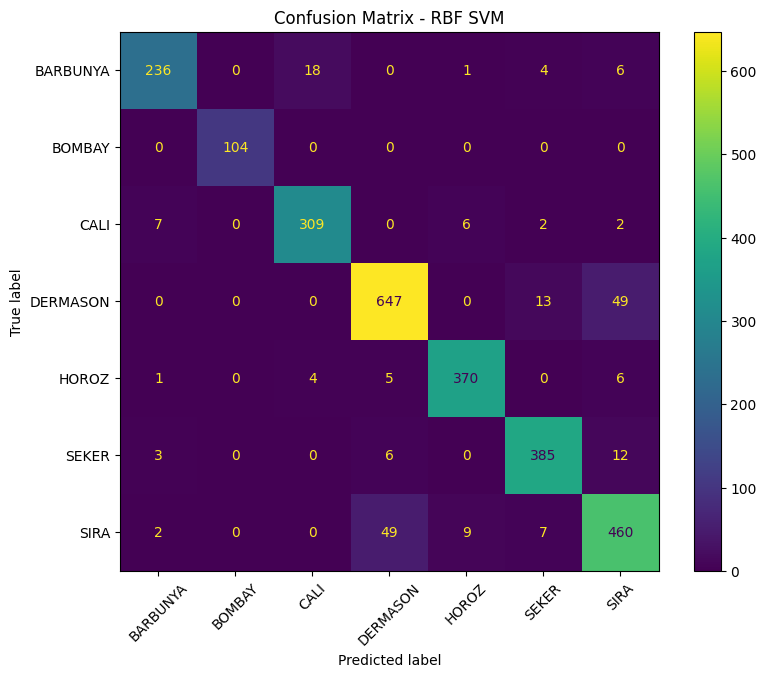

In [21]:
cm = confusion_matrix(y_test, y_pred_rbf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, xticks_rotation=45, cmap=None)

plt.title("Confusion Matrix - RBF SVM")
plt.grid(False)
plt.show()

The confusion matrix shows which bean classes are easier or harder to classify.

Misclassifications between similar bean types may happen because their shape features overlap.

## PCA Visualisation

The original dataset has many numerical features, so it is difficult to visualise directly.

I will use PCA to reduce the scaled feature space to 2 dimensions. This does not replace the full model, but it helps show how the classes are distributed visually.

In [22]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [23]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Class"] = y.values

pca_df.head()

,PC1,PC2,Class
0,-4.981561,1.824697,SEKER
1,-5.436792,2.932365,SEKER
2,-4.758088,1.826884,SEKER
3,-4.300541,2.003661,SEKER
4,-6.349340,4.088205,SEKER


In [24]:
explained_variance = pca.explained_variance_ratio_

print(f"PC1 explained variance: {explained_variance[0]:.2%}")
print(f"PC2 explained variance: {explained_variance[1]:.2%}")
print(f"Total explained variance: {explained_variance.sum():.2%}")

PC1 explained variance: 55.47%
PC2 explained variance: 26.43%
Total explained variance: 81.90%


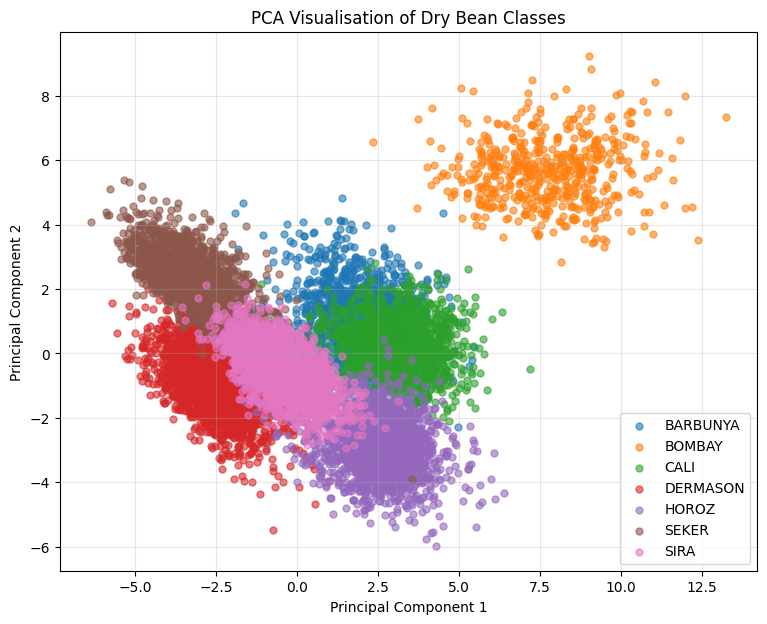

In [25]:
plt.figure(figsize=(9, 7))

for class_name in class_names:
    class_data = pca_df[pca_df["Class"] == class_name]
    
    plt.scatter(
        class_data["PC1"],
        class_data["PC2"],
        s=25,
        alpha=0.6,
        label=class_name
    )

plt.title("PCA Visualisation of Dry Bean Classes")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Small Hyperparameter Experiment

The `C` parameter controls how strongly the SVM tries to classify training points correctly.

- Smaller `C`: wider margin, more regularisation
- Larger `C`: narrower margin, less regularisation, tries harder to fit the training data

I will test a few `C` values for the RBF SVM.

In [26]:
c_values = [0.1, 1, 10, 100]

c_results = []

for c in c_values:
    model = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=c, gamma="scale", random_state=42))
    ])
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    c_results.append({
        "C": c,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_test, y_pred, average="weighted", zero_division=0)
    })

c_results_df = pd.DataFrame(c_results)

c_results_df

,C,Accuracy,Precision,Recall,F1-score
0,0.1,0.919941,0.921232,0.919941,0.920110
1,1.0,0.922145,0.922426,0.922145,0.922177
2,10.0,0.924348,0.924320,0.924348,0.924295
3,100.0,0.925083,0.925043,0.925083,0.924978


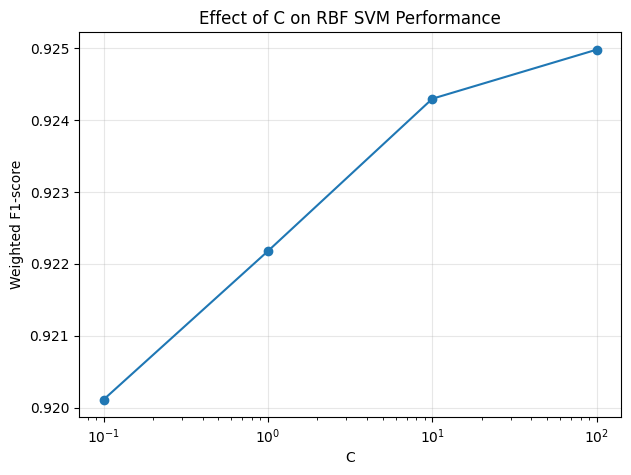

In [27]:
plt.figure(figsize=(7, 5))

plt.plot(c_results_df["C"], c_results_df["F1-score"], marker="o")

plt.xscale("log")
plt.title("Effect of C on RBF SVM Performance")
plt.xlabel("C")
plt.ylabel("Weighted F1-score")
plt.grid(alpha=0.3)
plt.show()

Changing `C` affects the balance between margin size and training error.

In this notebook, I only test a few values to understand the effect. A larger project could use cross-validation and grid search.